### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [ ]:
data = pd.read_csv('coupons.csv')

In [ ]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [ ]:

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

3. Decide what to do about your missing data -- drop, replace, other...

In [ ]:
#show columns with missing data
missing_data = data.isnull().sum()
print(missing_data)
#drop columns with more missing data
data_cleaned = data.drop(columns=['car'])
#Filling values
for col in ['CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50', 'Bar']:
    data_cleaned[col] = data_cleaned[col].fillna('never')
print(data_cleaned.isnull().sum())


destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64
destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0

4. What proportion of the total observations chose to accept the coupon?



In [ ]:
# Calculate proportion of accepted coupons
acceptance_rate = data_cleaned['Y'].mean()
print(f"Proportion of accepted coupons: {acceptance_rate:.3f}")

Proportion of accepted coupons: 0.568


5. Use a bar plot to visualize the `coupon` column.

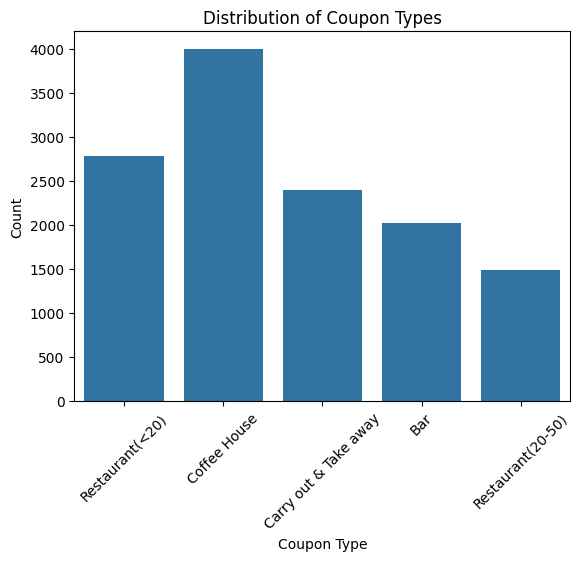

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot of coupon types
sns.countplot(x='coupon', data=data_cleaned)
plt.xticks(rotation=45)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.show()

6. Use a histogram to visualize the temperature column.

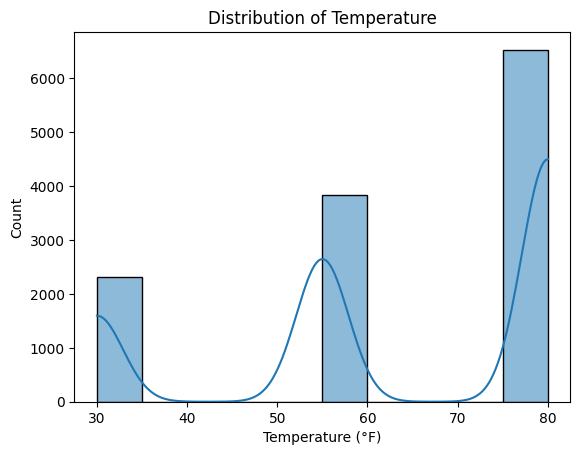

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for temperature column
sns.histplot(data_cleaned['temperature'], bins=10, kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°F)')
plt.ylabel('Count')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [ ]:
# Create a new DataFrame for Bar coupons
bar_coupons_df = data_cleaned[data_cleaned['coupon'] == 'Bar']

# Display the first few rows
print(bar_coupons_df.head())

        destination  passanger weather  temperature  time coupon expiration  \
9   No Urgent Place     Kid(s)   Sunny           80  10AM    Bar         1d   
13             Home      Alone   Sunny           55   6PM    Bar         1d   
17             Work      Alone   Sunny           55   7AM    Bar         1d   
24  No Urgent Place  Friend(s)   Sunny           80  10AM    Bar         1d   
35             Home      Alone   Sunny           55   6PM    Bar         1d   

    gender age      maritalStatus  ...  CoffeeHouse CarryAway  \
9   Female  21  Unmarried partner  ...        never     never   
13  Female  21  Unmarried partner  ...        never     never   
17  Female  21  Unmarried partner  ...        never     never   
24    Male  21             Single  ...        less1       4~8   
35    Male  21             Single  ...        less1       4~8   

   RestaurantLessThan20 Restaurant20To50 toCoupon_GEQ5min toCoupon_GEQ15min  \
9                   4~8              1~3               

2. What proportion of bar coupons were accepted?


In [ ]:
# Calculate the proportion of accepted bar coupons
bar_acceptance_rate = bar_coupons_df['Y'].mean()
print(f"Proportion of accepted bar coupons: {bar_acceptance_rate:.3f}")

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [ ]:
# Define categories for <=3 visits/month
few_bar_visits = ['0', 'less1', '1~3']
# Filter to bar-goers who visit <=3 times/month
few_bar_goers = bar_coupons_df[bar_coupons_df['Bar'].isin(few_bar_visits)]
# Calculate acceptance rate
few_accept_rate = few_bar_goers['Y'].mean()
print(f"Acceptance rate for bar-goers (≤3 times/month): {few_accept_rate:.3f}")

Acceptance rate for bar-goers (≤3 times/month): 0.527


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [ ]:
# Categories for >3 visits per month
many_visits = ['4~8', 'gt8']
many_bar_goers = bar_coupons_df[bar_coupons_df['Bar'].isin(many_visits)]
# Calculate acceptance rate
many_acceptance_rate = many_bar_goers['Y'].mean()
print(f"Acceptance rate (>3 times/month): {many_acceptance_rate:.3f}")

Acceptance rate (>3 times/month): 0.769


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [ ]:
# Categories for more than 3 times/month
many_bar_visits = ['4~8', 'gt8']
# Age groups over 25
age_over_25 = ['26', '31', '36', '41', '46', '50plus']
# Filter for frequent bar-goers over 25
frequent_adult_bar_goers = bar_coupons_df[
    bar_coupons_df['Bar'].isin(many_bar_visits) & bar_coupons_df['age'].isin(age_over_25)
]
# Calculate proportion accepted
acceptance_rate_freq_adult = frequent_adult_bar_goers['Y'].mean()
print(f"Acceptance rate (>3 times/month & over 25): {acceptance_rate_freq_adult:.3f}")

Acceptance rate (>3 times/month & over 25): 0.772


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [ ]:
# Categories for more than 1 time/month
more_than_once = ['1~3', '4~8', 'gt8']
# Age groups over 25
age_over_25 = ['26', '31', '36', '41', '46', '50plus']

# Filter for all criteria
selected_bar_goers = bar_coupons_df[
    (bar_coupons_df['Bar'].isin(more_than_once)) &
    (bar_coupons_df['age'].isin(age_over_25)) &
    (bar_coupons_df['passanger'] != 'Kid(s)') &
    (bar_coupons_df['occupation'] != 'Farming Fishing & Forestry')
]

# Calculate the proportion accepted
acceptance_rate_selected = selected_bar_goers['Y'].mean()
print(f"Acceptance rate (>1/month, age>25, not with kids, occupation not FFF): {acceptance_rate_selected:.3f}")

Acceptance rate (>1/month, age>25, not with kids, occupation not FFF): 0.735


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [ ]:
# Go to bars >1/month
more_than_once = ['1~3', '4~8', 'gt8']

filtered_bar_goers = bar_coupons_df[
    (bar_coupons_df['Bar'].isin(more_than_once)) &
    (bar_coupons_df['passanger'] != 'Kid(s)') &
    (bar_coupons_df['maritalStatus'] != 'Widowed')
]

acceptance_rate_filtered = filtered_bar_goers['Y'].mean()
print(f"Acceptance rate (>1/month, not with kids, not widowed): {acceptance_rate_filtered:.3f}")

Acceptance rate (>1/month, not with kids, not widowed): 0.713


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [ ]:
# Analyze bar coupon acceptance rates by income bracket
income_acceptance = bar_coupons_df.groupby('income')['Y'].mean().sort_values(ascending=False)
print(income_acceptance)

income
$100000 or More     0.474227
Less than $12500    0.460606
$25000 - $37499     0.449686
$12500 - $24999     0.416667
$50000 - $62499     0.412214
$75000 - $87499     0.377483
$62500 - $74999     0.353846
$37500 - $49999     0.348315
$87500 - $99999     0.317241
Name: Y, dtype: float64


In [ ]:
# Acceptance by marital status
marital_acceptance = bar_coupons_df.groupby('maritalStatus')['Y'].mean().sort_values(ascending=False)
print(marital_acceptance)

maritalStatus
Single               0.546142
Unmarried partner    0.399471
Widowed              0.333333
Married partner      0.328798
Divorced             0.240000
Name: Y, dtype: float64


In [ ]:
# Does going to less expensive restaurants affect bar coupon acceptance?
restaurant_acceptance = bar_coupons_df.groupby('RestaurantLessThan20')['Y'].mean().sort_values(ascending=False)
print(restaurant_acceptance)

RestaurantLessThan20
never    0.500000
gt8      0.456989
4~8      0.426056
1~3      0.396355
less1    0.375385
Name: Y, dtype: float64


In [ ]:
# Weather influence on acceptance?
weather_acceptance = bar_coupons_df.groupby('weather')['Y'].mean().sort_values(ascending=False)
print(weather_acceptance)

weather
Sunny    0.441395
Rainy    0.362791
Snowy    0.317992
Name: Y, dtype: float64


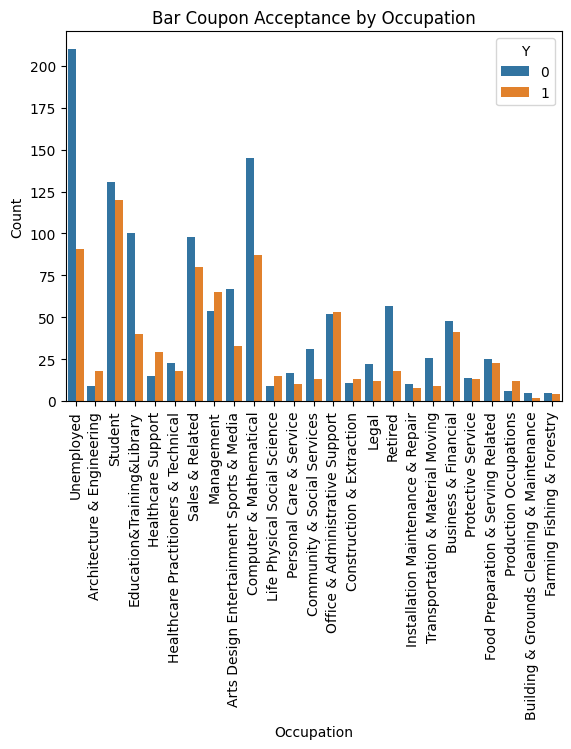

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Countplot of acceptance by occupation
sns.countplot(x='occupation', hue='Y', data=bar_coupons_df)
plt.title("Bar Coupon Acceptance by Occupation")
plt.xticks(rotation=90)
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.show()